In [1]:
import pandas as pd

df = pd.read_csv('c:/data/insta/instagram_usage_lifestyle.csv')
df.head()

,user_id,app_name,age,gender,country,income_level,employment_status,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,...,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count
0,1,Instagram,51,Female,India,High,Retired,7.2,7.7,3,...,12,12,4,1,2,1,1,2,374,647
1,2,Instagram,64,Female,United Kingdom,Middle,Full-time employed,10.9,8.6,1,...,18,10,11,1,31,19,16,19,2585,3511
2,3,Instagram,41,Female,Canada,Middle,Student,5.0,6.7,4,...,12,13,4,0,3,1,1,1,3414,6761
3,4,Instagram,27,Non-binary,South Korea,Middle,Unemployed,10.6,6.5,18,...,31,32,33,3,108,64,52,64,617,1193
4,5,Instagram,55,Male,India,Upper-middle,Full-time employed,7.7,6.8,19,...,29,37,20,5,78,55,22,55,1157,1072


In [2]:
df.columns

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'income_level',
       'employment_status', 'exercise_hours_per_week', 'sleep_hours_per_night',
       'perceived_stress_score', 'self_reported_happiness',
       'daily_steps_count', 'weekly_work_hours',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_messages_per_day', 'time_on_reels_per_day', 'followers_count',
       'following_count'],
      dtype='object')

In [3]:
train_cols = ['daily_active_minutes_instagram','time_on_feed_per_day','dms_received_per_week']
target_col = 'perceived_stress_score'
X = df[train_cols]
y = df[target_col]

In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
hist = model.fit(X_train,y_train,epochs=3,verbose=1)

Epoch 1/3
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 20s 736us/step - loss: 45.7855
Epoch 2/3
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 41.1046
Epoch 3/3
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 44s 1ms/step - loss: 41.0965


In [8]:
import numpy as np

x1 = np.array([[184, 78, 37]], dtype=float)
x1_scaled = scaler.transform(x1)
model.predict(x1_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


C:\python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[19.750202]], dtype=float32)

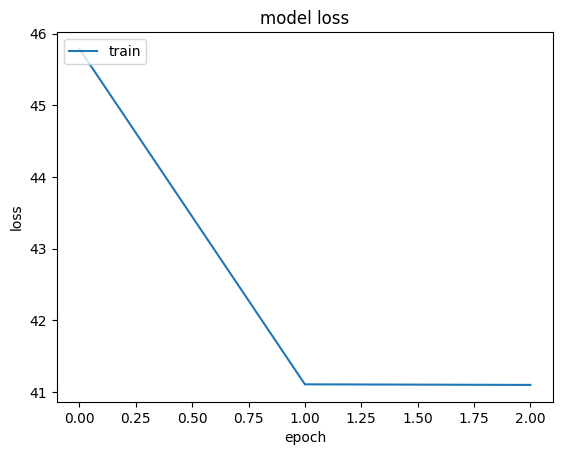

In [9]:
plt.plot(hist.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()